## Импорты и настройка

In [ ]:
from pathlib import Path
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


# Фиксируем seed, чтобы результаты были более воспроизводимыми.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


# Основные параметры эксперимента.
IMAGE_SIZE = 64
CHANNELS = 3
BATCH_SIZE = 64
LATENT_DIM = 100

# Для первого теста можно поставить 5-10 эпох.
# Потом, если всё работает, увеличить.
EPOCHS = 10

In [ ]:
# Пути к данным

DATA_DIR = Path.cwd())

# В Kaggle-архиве LFW вложенная папка:
# lfw-deepfunneled/lfw-deepfunneled/person_name/image.jpg
IMAGE_DIR = DATA_DIR / "lfw-deepfunneled" / "lfw-deepfunneled"

print("DATA_DIR:", DATA_DIR)
print("IMAGE_DIR:", IMAGE_DIR)
print("IMAGE_DIR exists:", IMAGE_DIR.exists())

DATA_DIR: C:\Users\user\ml-deep-learning\9. advanced
IMAGE_DIR: C:\Users\user\ml-deep-learning\9. advanced\lfw-deepfunneled\lfw-deepfunneled
IMAGE_DIR exists: True


In [ ]:
# Сбор путей к изображениям

image_paths = sorted(IMAGE_DIR.glob("*/*.jpg"))

print("Количество изображений:", len(image_paths))
print("Пример пути:", image_paths[0] if len(image_paths) > 0 else "Нет изображений")

Количество изображений: 13233
Пример пути: C:\Users\user\ml-deep-learning\9. advanced\lfw-deepfunneled\lfw-deepfunneled\Aaron_Eckhart\Aaron_Eckhart_0001.jpg


In [ ]:
# Базовый обзор датасета

# Имя человека берем из названия родительской папки.
people = [path.parent.name for path in image_paths]

people_df = pd.DataFrame({
    "image_path": [str(path) for path in image_paths],
    "person": people
})

print("Количество изображений:", len(people_df))
print("Количество уникальных людей:", people_df["person"].nunique())

display(people_df.head())


# Сколько изображений приходится на каждого человека.
person_counts = people_df["person"].value_counts()

print("Минимум изображений на человека:", person_counts.min())
print("Максимум изображений на человека:", person_counts.max())
print("Среднее количество изображений на человека:", person_counts.mean().round(2))

display(person_counts.head(10))

Количество изображений: 13233
Количество уникальных людей: 5749


,image_path,person
0,C:\Users\user\ml-deep-learning\9. advanced\lfw...,Aaron_Eckhart
1,C:\Users\user\ml-deep-learning\9. advanced\lfw...,Aaron_Guiel
2,C:\Users\user\ml-deep-learning\9. advanced\lfw...,Aaron_Patterson
3,C:\Users\user\ml-deep-learning\9. advanced\lfw...,Aaron_Peirsol
4,C:\Users\user\ml-deep-learning\9. advanced\lfw...,Aaron_Peirsol


Минимум изображений на человека: 1
Максимум изображений на человека: 530
Среднее количество изображений на человека: 2.3


person
George_W_Bush        530
Colin_Powell         236
Tony_Blair           144
Donald_Rumsfeld      121
Gerhard_Schroeder    109
Ariel_Sharon          77
Hugo_Chavez           71
Junichiro_Koizumi     60
Jean_Chretien         55
John_Ashcroft         53
Name: count, dtype: int64

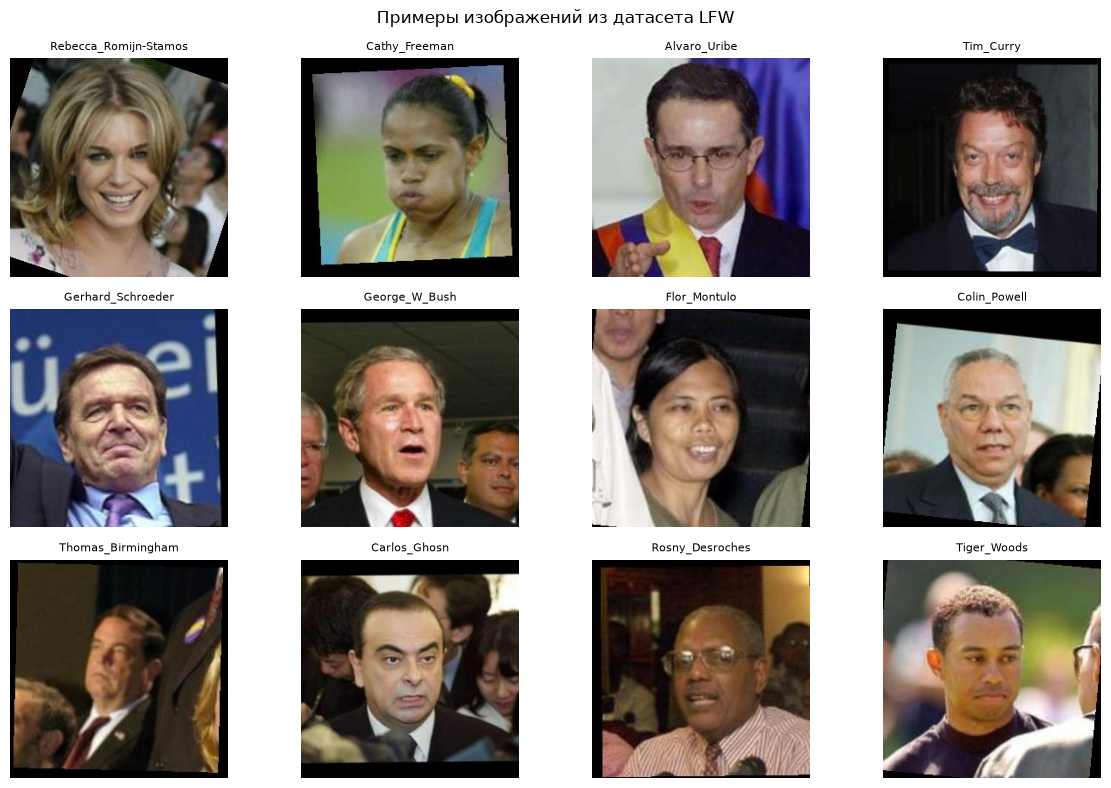

In [ ]:
# Примеры изображений из LFW

sample_paths = random.sample(image_paths, k=min(12, len(image_paths)))

plt.figure(figsize=(12, 8))

for i, path in enumerate(sample_paths):
    image = Image.open(path).convert("RGB")

    plt.subplot(3, 4, i + 1)
    plt.imshow(image)
    plt.title(path.parent.name, fontsize=8)
    plt.axis("off")

plt.suptitle("Примеры изображений из датасета LFW")
plt.tight_layout()
plt.show()

## Проверка размеров и предобработка

In [ ]:
# Проверка размеров исходных изображений

# Проверим размеры у небольшой выборки изображений.
sample_for_size_check = random.sample(image_paths, k=min(200, len(image_paths)))

image_sizes = []

for path in sample_for_size_check:
    image = Image.open(path)
    image_sizes.append(image.size)

sizes_df = pd.DataFrame(image_sizes, columns=["width", "height"])

print("Уникальные размеры в проверенной выборке:")
display(sizes_df.value_counts().reset_index(name="count").head())

print("Минимальная ширина:", sizes_df["width"].min())
print("Максимальная ширина:", sizes_df["width"].max())
print("Минимальная высота:", sizes_df["height"].min())
print("Максимальная высота:", sizes_df["height"].max())

Уникальные размеры в проверенной выборке:


,width,height,count
0,250,250,200


Минимальная ширина: 250
Максимальная ширина: 250
Минимальная высота: 250
Максимальная высота: 250


In [ ]:
# Предобработка одного изображения

def preprocess_image(path):
    """Загружает изображение, приводит к RGB, resize 64x64 и нормализует в [-1, 1]."""
    # Открываем изображение и гарантируем 3 RGB-канала.
    image = Image.open(path).convert("RGB")

    # Меняем размер до фиксированного IMAGE_SIZE x IMAGE_SIZE.
    image = image.resize((IMAGE_SIZE, IMAGE_SIZE))

    # Переводим изображение в numpy-массив.
    image_array = np.array(image, dtype=np.float32)

    # Нормализуем пиксели из [0, 255] в [-1, 1].
    image_array = (image_array / 127.5) - 1.0

    return image_array

In [ ]:
# Проверка предобработки

example_image = preprocess_image(image_paths[0])

print("Shape after preprocessing:", example_image.shape)
print("Min pixel value:", example_image.min())
print("Max pixel value:", example_image.max())

Shape after preprocessing: (64, 64, 3)
Min pixel value: -1.0
Max pixel value: 0.8352941


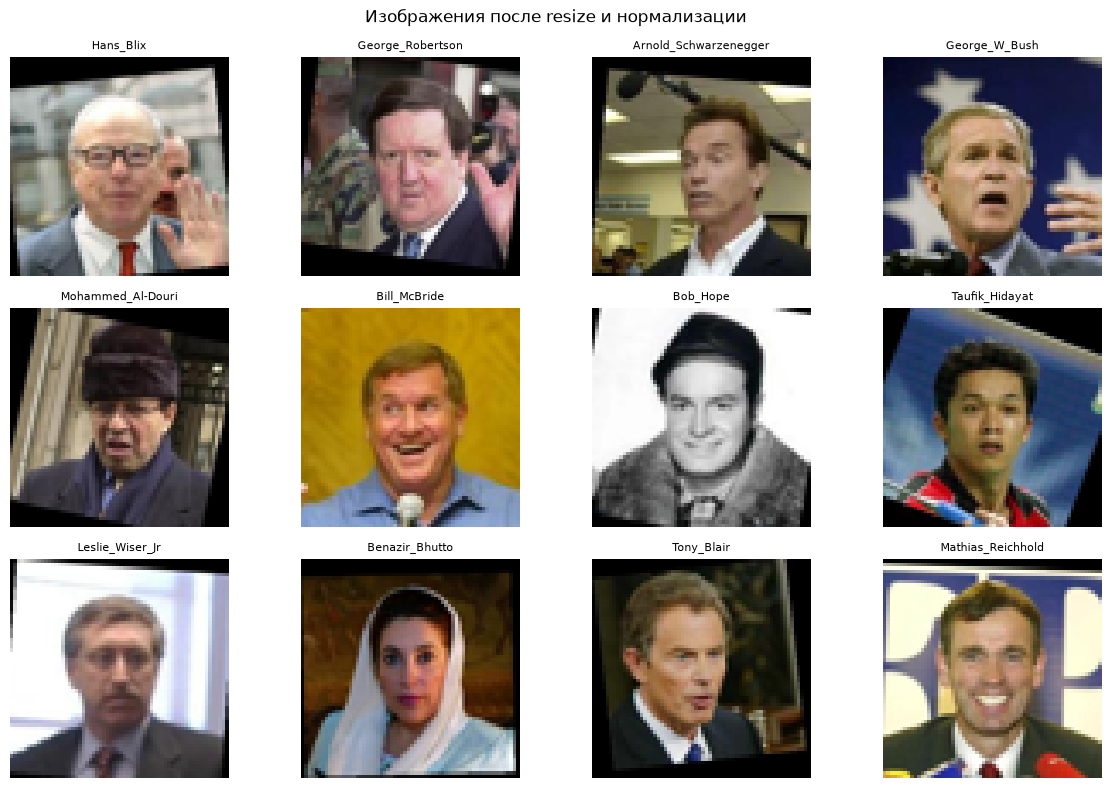

In [ ]:
# Визуализация изображений после предобработки

def denormalize_image(image):
    """Возвращает изображение из диапазона [-1, 1] обратно в [0, 1] для отображения."""
    return (image + 1.0) / 2.0


sample_paths = random.sample(image_paths, k=min(12, len(image_paths)))

plt.figure(figsize=(12, 8))

for i, path in enumerate(sample_paths):
    image = preprocess_image(path)

    plt.subplot(3, 4, i + 1)
    plt.imshow(denormalize_image(image))
    plt.title(path.parent.name, fontsize=8)
    plt.axis("off")

plt.suptitle("Изображения после resize и нормализации")
plt.tight_layout()
plt.show()

In [ ]:
# Создание TensorFlow Dataset

def load_image_tf(path):
    """TensorFlow-версия загрузки и предобработки изображения."""
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [IMAGE_SIZE, IMAGE_SIZE])
    image = tf.cast(image, tf.float32)

    # Нормализация в [-1, 1], так как генератор использует tanh.
    image = (image / 127.5) - 1.0

    return image


# Преобразуем пути в строки.
image_path_strings = [str(path) for path in image_paths]

# Перемешиваем список путей до разделения, чтобы выборки были случайными.
random.Random(SEED).shuffle(image_path_strings)

# Явно задаем пропорции train/val.
TRAIN_RATIO = 0.8
VAL_RATIO = 0.2

train_size = int(len(image_path_strings) * TRAIN_RATIO)

train_paths = image_path_strings[:train_size]
val_paths = image_path_strings[train_size:]

print("Всего изображений:", len(image_path_strings))
print(f"Train: {len(train_paths)} изображений ({TRAIN_RATIO:.0%})")
print(f"Val: {len(val_paths)} изображений ({VAL_RATIO:.0%})")


def make_dataset(paths, shuffle=False):
    """Создает tf.data.Dataset из списка путей."""
    ds = tf.data.Dataset.from_tensor_slices(paths)

    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED)

    ds = (
        ds
        .map(load_image_tf, num_parallel_calls=tf.data.AUTOTUNE)
        .batch(BATCH_SIZE)
        .prefetch(tf.data.AUTOTUNE)
    )

    return ds


# Train dataset используется для обучения моделей.
train_dataset = make_dataset(train_paths, shuffle=True)

# Val dataset используется только для визуализации и проверки.
val_dataset = make_dataset(val_paths, shuffle=False)

print("Train/val datasets готовы")

Всего изображений: 13233
Train: 10586 изображений (80%)
Val: 2647 изображений (20%)
Train/val datasets готовы


In [ ]:
# Проверка одного batch из train_dataset

real_batch = next(iter(train_dataset))

print("Train batch shape:", real_batch.shape)
print("Min pixel value:", tf.reduce_min(real_batch).numpy())
print("Max pixel value:", tf.reduce_max(real_batch).numpy())

Train batch shape: (64, 64, 64, 3)
Min pixel value: -1.0
Max pixel value: 1.0


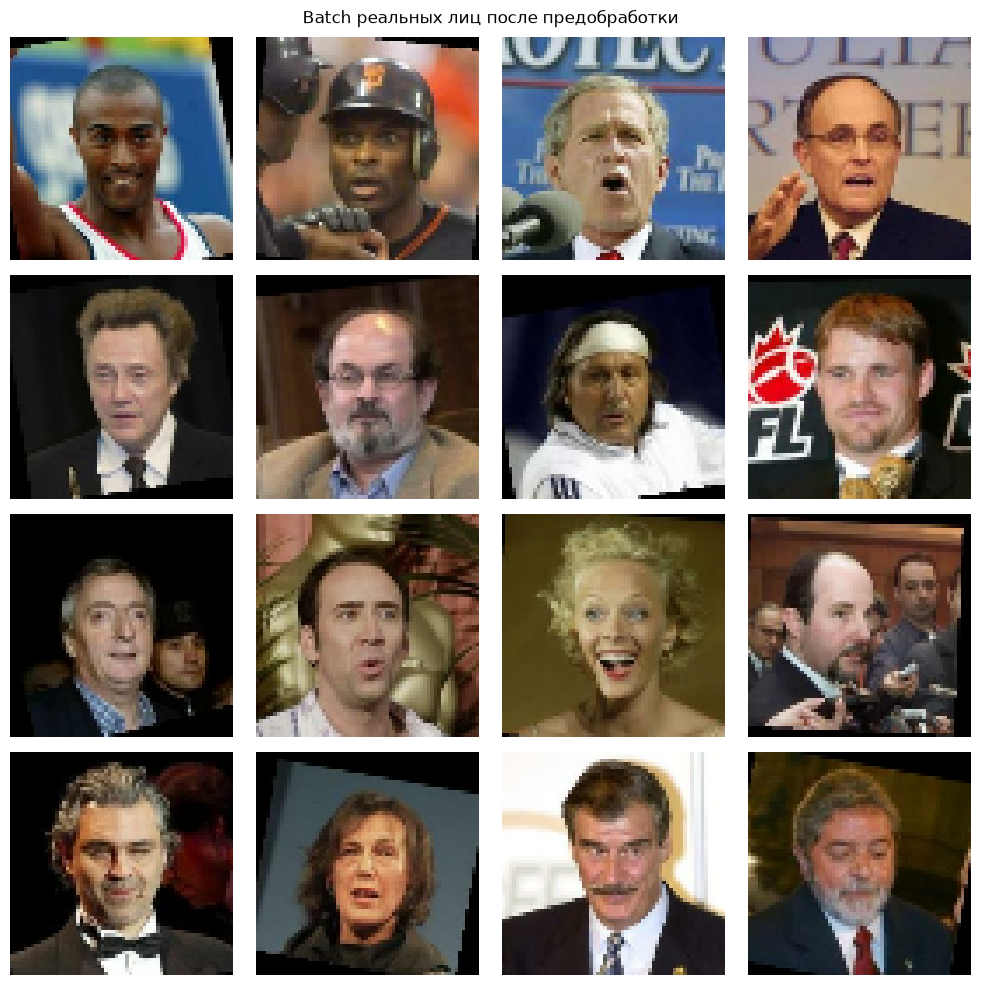

In [ ]:
# Визуализация batch после TensorFlow-предобработки

plt.figure(figsize=(10, 10))

for i in range(min(16, real_batch.shape[0])):
    plt.subplot(4, 4, i + 1)

    # Возвращаем изображение из [-1, 1] в [0, 1] для matplotlib.
    image = (real_batch[i].numpy() + 1.0) / 2.0

    plt.imshow(image)
    plt.axis("off")

plt.suptitle("Batch реальных лиц после предобработки")
plt.tight_layout()
plt.show()

## Generator model

In [ ]:
# Generator model

def build_generator():
    """Создает генератор DCGAN: latent vector -> изображение лица 64x64x3."""
    model = keras.Sequential(name="generator")

    # Вход: случайный latent vector размерности LATENT_DIM.
    model.add(layers.Input(shape=(LATENT_DIM,)))

    # Превращаем latent vector в набор признаков 4x4x512.
    model.add(layers.Dense(4 * 4 * 512, use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    # Меняем форму в feature map.
    model.add(layers.Reshape((4, 4, 512)))

    # 4x4 -> 8x8.
    model.add(
        layers.Conv2DTranspose(
            256,
            kernel_size=4,
            strides=2,
            padding="same",
            use_bias=False
        )
    )
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    # 8x8 -> 16x16.
    model.add(
        layers.Conv2DTranspose(
            128,
            kernel_size=4,
            strides=2,
            padding="same",
            use_bias=False
        )
    )
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    # 16x16 -> 32x32.
    model.add(
        layers.Conv2DTranspose(
            64,
            kernel_size=4,
            strides=2,
            padding="same",
            use_bias=False
        )
    )
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    # 32x32 -> 64x64.
    # tanh нужен, потому что реальные изображения нормализованы в [-1, 1].
    model.add(
        layers.Conv2DTranspose(
            CHANNELS,
            kernel_size=4,
            strides=2,
            padding="same",
            activation="tanh"
        )
    )

    return model


generator = build_generator()
generator.summary()

Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8192)           │       819,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 8192)           │        32,768 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 8, 8, 256)      │     2,097,152 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 16, 16, 128)    │       524,288 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 32, 32, 64)     │       131,072 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 64, 64, 3)      │         3,075 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,609,347 (13.77 MB)

 Trainable params: 3,592,067 (13.70 MB)

 Non-trainable params: 17,280 (67.50 KB)

Generated image shape: (1, 64, 64, 3)
Min value: -0.022612607
Max value: 0.02109843


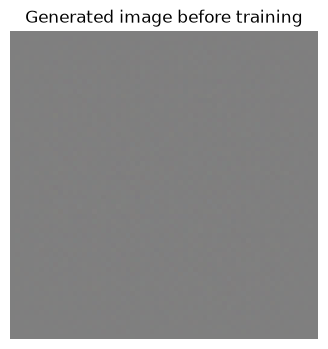

In [ ]:
# Проверка генератора до обучения

# Создаем случайный latent vector.
noise = tf.random.normal([1, LATENT_DIM])

# Генератор создает одно изображение.
generated_image = generator(noise, training=False)

print("Generated image shape:", generated_image.shape)
print("Min value:", tf.reduce_min(generated_image).numpy())
print("Max value:", tf.reduce_max(generated_image).numpy())

# Показываем случайное изображение до обучения.
plt.figure(figsize=(4, 4))
plt.imshow((generated_image[0].numpy() + 1.0) / 2.0)
plt.title("Generated image before training")
plt.axis("off")
plt.show()

## Discriminator model

In [ ]:
# Discriminator model

def build_discriminator():
    """Создает дискриминатор DCGAN: изображение 64x64x3 -> real/fake logit."""
    model = keras.Sequential(name="discriminator")

    # Вход: изображение лица 64x64x3.
    model.add(layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, CHANNELS)))

    # 64x64 -> 32x32.
    # Дискриминатор постепенно сжимает изображение и выделяет признаки.
    model.add(
        layers.Conv2D(
            64,
            kernel_size=4,
            strides=2,
            padding="same"
        )
    )
    model.add(layers.LeakyReLU(alpha=0.2))
    model.add(layers.Dropout(0.3))

    # 32x32 -> 16x16.
    model.add(
        layers.Conv2D(
            128,
            kernel_size=4,
            strides=2,
            padding="same"
        )
    )
    model.add(layers.LeakyReLU(alpha=0.2))
    model.add(layers.Dropout(0.3))

    # 16x16 -> 8x8.
    model.add(
        layers.Conv2D(
            256,
            kernel_size=4,
            strides=2,
            padding="same"
        )
    )
    model.add(layers.LeakyReLU(alpha=0.2))
    model.add(layers.Dropout(0.3))

    # Превращаем карты признаков в один вектор.
    model.add(layers.Flatten())

    # Один выход без sigmoid.
    # Это logit, потому что дальше используем BinaryCrossentropy(from_logits=True).
    model.add(layers.Dense(1))

    return model


discriminator = build_discriminator()
discriminator.summary()

C:\Users\user\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 128)    │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 256)      │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │        16,385 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 675,265 (2.58 MB)

 Trainable params: 675,265 (2.58 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Проверка дискриминатора

# Пропускаем одно реальное изображение через дискриминатор.
real_output = discriminator(real_batch[:1], training=False)

# Пропускаем одно сгенерированное изображение через дискриминатор.
fake_output = discriminator(generated_image, training=False)

print("Real output shape:", real_output.shape)
print("Fake output shape:", fake_output.shape)
print("Real output:", real_output.numpy())
print("Fake output:", fake_output.numpy())

Real output shape: (1, 1)
Fake output shape: (1, 1)
Real output: [[-0.0537172]]
Fake output: [[-0.00156704]]


## Обучение GAN

In [ ]:
# Loss functions and optimizers

# BinaryCrossentropy сравнивает реальные/фейковые метки.
# from_logits=True, потому что дискриминатор возвращает не sigmoid-вероятность, а logit.
cross_entropy = keras.losses.BinaryCrossentropy(from_logits=True)


def discriminator_loss(real_output, fake_output):
    """Loss дискриминатора: отличать реальные изображения от сгенерированных."""
    # Реальные изображения должны получать метку 1.
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)

    # Сгенерированные изображения должны получать метку 0.
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)

    # Общий loss дискриминатора.
    total_loss = real_loss + fake_loss

    return total_loss


def generator_loss(fake_output):
    """Loss генератора: заставить дискриминатор принять fake-изображения за реальные."""
    # Генератор хочет, чтобы дискриминатор считал fake-изображения реальными.
    return cross_entropy(tf.ones_like(fake_output), fake_output)


# Adam с beta_1=0.5 часто используют в DCGAN для более стабильного обучения.
generator_optimizer = keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)
discriminator_optimizer = keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)

In [ ]:
# One GAN training step

@tf.function
def train_step(real_images):
    """Выполняет один шаг обучения генератора и дискриминатора."""
    # Размер текущего batch может быть меньше BATCH_SIZE на последней итерации.
    current_batch_size = tf.shape(real_images)[0]

    # Генерируем случайный шум для текущего batch.
    noise = tf.random.normal([current_batch_size, LATENT_DIM])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        # Генератор создает fake-изображения.
        generated_images = generator(noise, training=True)

        # Дискриминатор оценивает реальные изображения.
        real_output = discriminator(real_images, training=True)

        # Дискриминатор оценивает fake-изображения.
        fake_output = discriminator(generated_images, training=True)

        # Считаем loss генератора.
        gen_loss = generator_loss(fake_output)

        # Считаем loss дискриминатора.
        disc_loss = discriminator_loss(real_output, fake_output)

    # Градиенты генератора.
    gradients_of_generator = gen_tape.gradient(
        gen_loss,
        generator.trainable_variables
    )

    # Градиенты дискриминатора.
    gradients_of_discriminator = disc_tape.gradient(
        disc_loss,
        discriminator.trainable_variables
    )

    # Обновляем веса генератора.
    generator_optimizer.apply_gradients(
        zip(gradients_of_generator, generator.trainable_variables)
    )

    # Обновляем веса дискриминатора.
    discriminator_optimizer.apply_gradients(
        zip(gradients_of_discriminator, discriminator.trainable_variables)
    )

    return gen_loss, disc_loss

In [ ]:
# Проверка одного шага обучения train batch

test_batch = next(iter(train_dataset))

test_gen_loss, test_disc_loss = train_step(test_batch)

print("Generator loss:", float(test_gen_loss))
print("Discriminator loss:", float(test_disc_loss))

Generator loss: 0.7325822114944458
Discriminator loss: 1.4128549098968506


In [ ]:
# Function for showing generated images

# Фиксированный шум нужен, чтобы сравнивать прогресс генератора от эпохи к эпохе.
fixed_noise = tf.random.normal([16, LATENT_DIM])


def show_generated_images(epoch, noise=fixed_noise):
    """Показывает 16 изображений, сгенерированных моделью."""
    # Генерируем изображения без обучения.
    generated_images = generator(noise, training=False)

    plt.figure(figsize=(8, 8))

    for i in range(generated_images.shape[0]):
        plt.subplot(4, 4, i + 1)

        # Возвращаем изображение из [-1, 1] в [0, 1].
        image = (generated_images[i].numpy() + 1.0) / 2.0

        # Ограничиваем значения, чтобы matplotlib корректно отрисовал картинку.
        image = np.clip(image, 0, 1)

        plt.imshow(image)
        plt.axis("off")

    plt.suptitle(f"Generated faces after epoch {epoch}")
    plt.tight_layout()
    plt.show()

In [ ]:
# GAN training loop

# Здесь будем хранить средний loss генератора по эпохам.
gen_loss_history = []

# Здесь будем хранить средний loss дискриминатора по эпохам.
disc_loss_history = []


def train_gan(dataset, epochs):
    """Обучает GAN и показывает генерации после каждой эпохи."""
    for epoch in range(1, epochs + 1):
        start_time = time.time()

        # Loss-ы внутри текущей эпохи.
        epoch_gen_losses = []
        epoch_disc_losses = []

        for real_images in dataset:
            # Выполняем один шаг обучения GAN.
            gen_loss, disc_loss = train_step(real_images)

            # Сохраняем loss-и текущего batch.
            epoch_gen_losses.append(float(gen_loss))
            epoch_disc_losses.append(float(disc_loss))

        # Считаем средние loss-и за эпоху.
        mean_gen_loss = np.mean(epoch_gen_losses)
        mean_disc_loss = np.mean(epoch_disc_losses)

        # Сохраняем историю для последующих графиков.
        gen_loss_history.append(mean_gen_loss)
        disc_loss_history.append(mean_disc_loss)

        # Печатаем прогресс обучения.
        print(
            f"Epoch {epoch}/{epochs} | "
            f"Generator loss: {mean_gen_loss:.4f} | "
            f"Discriminator loss: {mean_disc_loss:.4f} | "
            f"Time: {time.time() - start_time:.1f}s"
        )

        # Показываем лица после каждой эпохи.
        show_generated_images(epoch)

In [ ]:
# Start GAN training

train_gan(train_dataset, EPOCHS)

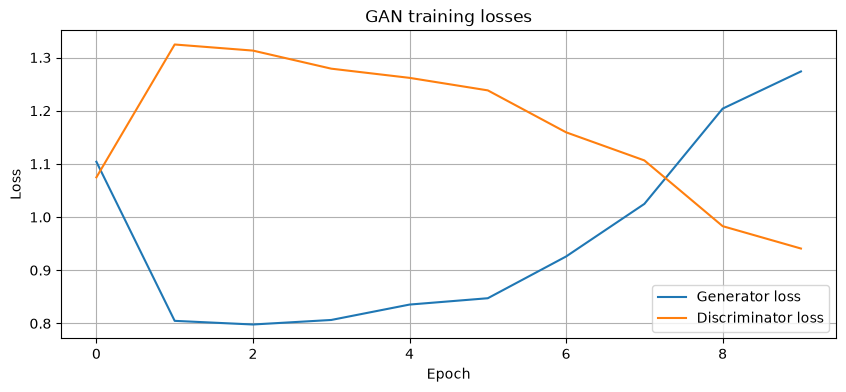

In [ ]:
# Training loss plots

plt.figure(figsize=(10, 4))

plt.plot(gen_loss_history, label="Generator loss")
plt.plot(disc_loss_history, label="Discriminator loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GAN training losses")
plt.grid()
plt.legend()
plt.show()

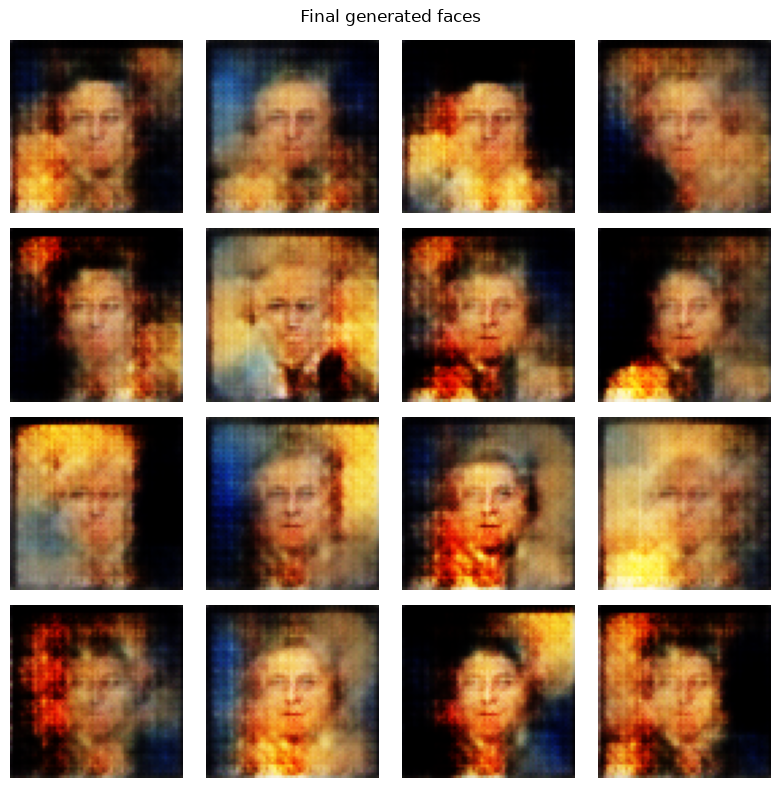

In [ ]:
# Final generated faces

# Генерируем новый случайный шум.
final_noise = tf.random.normal([16, LATENT_DIM])

# Получаем финальные изображения от обученного генератора.
final_generated_images = generator(final_noise, training=False)

plt.figure(figsize=(8, 8))

for i in range(final_generated_images.shape[0]):
    plt.subplot(4, 4, i + 1)

    # Возвращаем изображение из [-1, 1] в [0, 1].
    image = (final_generated_images[i].numpy() + 1.0) / 2.0
    image = np.clip(image, 0, 1)

    plt.imshow(image)
    plt.axis("off")

plt.suptitle("Final generated faces")
plt.tight_layout()
plt.show()

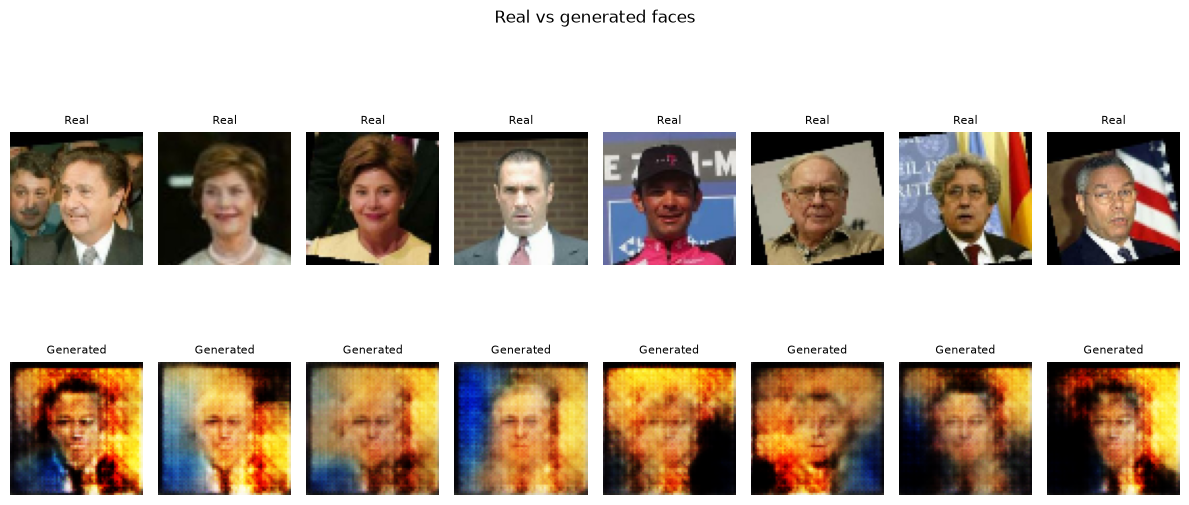

In [ ]:
# Real vs generated faces

# Берем один batch реальных изображений.
real_images = next(iter(val_dataset))

# Генерируем столько же fake-изображений для сравнения.
comparison_noise = tf.random.normal([8, LATENT_DIM])
generated_images = generator(comparison_noise, training=False)

plt.figure(figsize=(12, 6))

for i in range(8):
    # Верхний ряд: реальные лица.
    plt.subplot(2, 8, i + 1)
    real_image = (real_images[i].numpy() + 1.0) / 2.0
    real_image = np.clip(real_image, 0, 1)
    plt.imshow(real_image)
    plt.title("Real", fontsize=8)
    plt.axis("off")

    # Нижний ряд: сгенерированные лица.
    plt.subplot(2, 8, i + 1 + 8)
    fake_image = (generated_images[i].numpy() + 1.0) / 2.0
    fake_image = np.clip(fake_image, 0, 1)
    plt.imshow(fake_image)
    plt.title("Generated", fontsize=8)
    plt.axis("off")

plt.suptitle("Real vs generated faces")
plt.tight_layout()
plt.show()

## VAE

In [ ]:
# VAE settings

# Размер latent-пространства VAE.
VAE_LATENT_DIM = 128

# Для демонстрационного обучения VAE достаточно 5-10 эпох.
VAE_EPOCHS = 5

In [ ]:
# Sampling layer for VAE

class Sampling(layers.Layer):
    """Слой reparameterization trick: z = mean + exp(0.5 * log_var) * epsilon."""

    def call(self, inputs):
        # Получаем параметры распределения из encoder.
        z_mean, z_log_var = inputs

        # Размер batch берем динамически.
        batch = tf.shape(z_mean)[0]

        # Размерность latent-пространства.
        dim = tf.shape(z_mean)[1]

        # Случайный шум из нормального распределения.
        epsilon = tf.random.normal(shape=(batch, dim))

        # Reparameterization trick позволяет обучать encoder через backpropagation.
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

In [ ]:
# VAE encoder

def build_vae_encoder():
    """Encoder: изображение 64x64x3 -> z_mean, z_log_var, z."""
    encoder_inputs = keras.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, CHANNELS))

    x = layers.Conv2D(32, 3, strides=2, padding="same", activation="relu")(encoder_inputs)
    x = layers.Conv2D(64, 3, strides=2, padding="same", activation="relu")(x)
    x = layers.Conv2D(128, 3, strides=2, padding="same", activation="relu")(x)
    x = layers.Conv2D(256, 3, strides=2, padding="same", activation="relu")(x)

    x = layers.Flatten()(x)
    x = layers.Dense(256, activation="relu")(x)

    z_mean = layers.Dense(VAE_LATENT_DIM, name="z_mean")(x)
    z_log_var = layers.Dense(VAE_LATENT_DIM, name="z_log_var")(x)
    z = Sampling()([z_mean, z_log_var])

    encoder = keras.Model(
        encoder_inputs,
        [z_mean, z_log_var, z],
        name="vae_encoder"
    )

    return encoder


vae_encoder = build_vae_encoder()
vae_encoder.summary()

Model: "vae_encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 32, 32,    │        896 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 16, 16,    │     18,496 │ conv2d_3[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 8, 8, 128) │     73,856 │ conv2d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 4, 4, 256) │    295,168 │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 4096)      │          0 │ conv2d_6[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │  1,048,832 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 128)       │     32,896 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 128)       │     32,896 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling (Sampling) │ (None, 128)       │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,503,040 (5.73 MB)

 Trainable params: 1,503,040 (5.73 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# VAE decoder

def build_vae_decoder():
    """Decoder: latent vector -> изображение 64x64x3."""
    latent_inputs = keras.Input(shape=(VAE_LATENT_DIM,))

    x = layers.Dense(4 * 4 * 256, activation="relu")(latent_inputs)
    x = layers.Reshape((4, 4, 256))(x)

    x = layers.Conv2DTranspose(128, 3, strides=2, padding="same", activation="relu")(x)
    x = layers.Conv2DTranspose(64, 3, strides=2, padding="same", activation="relu")(x)
    x = layers.Conv2DTranspose(32, 3, strides=2, padding="same", activation="relu")(x)
    x = layers.Conv2DTranspose(16, 3, strides=2, padding="same", activation="relu")(x)

    # tanh, потому что изображения нормализованы в [-1, 1].
    decoder_outputs = layers.Conv2D(
        CHANNELS,
        3,
        padding="same",
        activation="tanh"
    )(x)

    decoder = keras.Model(
        latent_inputs,
        decoder_outputs,
        name="vae_decoder"
    )

    return decoder


vae_decoder = build_vae_decoder()
vae_decoder.summary()

Model: "vae_decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4096)           │       528,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 8, 8, 128)      │       295,040 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_5              │ (None, 16, 16, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_6              │ (None, 32, 32, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_7              │ (None, 64, 64, 16)     │         4,624 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 64, 64, 3)      │           435 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 920,739 (3.51 MB)

 Trainable params: 920,739 (3.51 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# VAE model

class VAE(keras.Model):
    """VAE с reconstruction loss и KL-divergence loss."""

    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)

        self.encoder = encoder
        self.decoder = decoder

        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def train_step(self, data):
        # Если dataset вернул tuple, берем только изображения.
        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:
            # Encoder получает изображение и возвращает параметры latent distribution.
            z_mean, z_log_var, z = self.encoder(data)

            # Decoder восстанавливает изображение из latent vector.
            reconstruction = self.decoder(z)

            # Reconstruction loss: насколько восстановление похоже на оригинал.
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    tf.square(data - reconstruction),
                    axis=(1, 2, 3)
                )
            )

            # KL loss: приближает latent distribution к нормальному распределению.
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                    axis=1
                )
            )

            # Общий loss VAE.
            total_loss = reconstruction_loss + kl_loss

        # Считаем градиенты.
        grads = tape.gradient(total_loss, self.trainable_weights)

        # Обновляем веса encoder и decoder.
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        # Обновляем метрики.
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "total_loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }


vae = VAE(vae_encoder, vae_decoder)
vae.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0005))

In [ ]:
#  Train VAE

vae_history = vae.fit(
    train_dataset,
    epochs=VAE_EPOCHS
)

Epoch 1/5


C:\Users\user\AppData\Roaming\Python\Python313\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


166/166 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - kl_loss: 57.1877 - reconstruction_loss: 2789.0620 - total_loss: 2846.2495
Epoch 2/5
166/166 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - kl_loss: 113.2358 - reconstruction_loss: 1542.7797 - total_loss: 1656.0160
Epoch 3/5
166/166 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - kl_loss: 130.0265 - reconstruction_loss: 1264.0496 - total_loss: 1394.0763
Epoch 4/5
166/166 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - kl_loss: 137.2603 - reconstruction_loss: 1144.8555 - total_loss: 1282.1154
Epoch 5/5
166/166 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - kl_loss: 141.0587 - reconstruction_loss: 1067.9712 - total_loss: 1209.0302


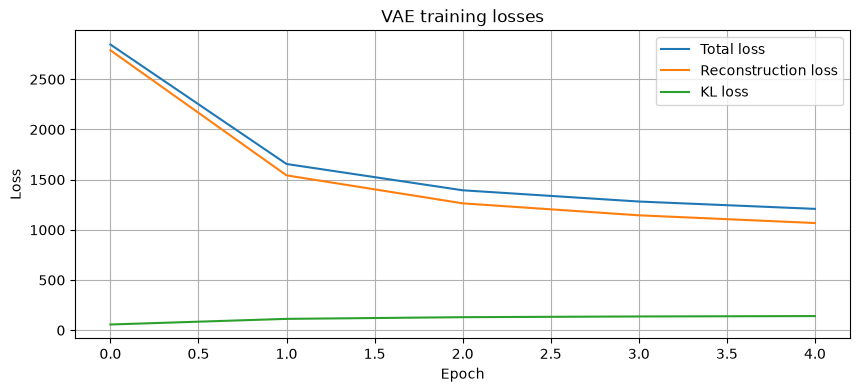

In [ ]:
# VAE training loss plots

plt.figure(figsize=(10, 4))

plt.plot(vae_history.history["total_loss"], label="Total loss")
plt.plot(vae_history.history["reconstruction_loss"], label="Reconstruction loss")
plt.plot(vae_history.history["kl_loss"], label="KL loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VAE training losses")
plt.grid()
plt.legend()
plt.show()

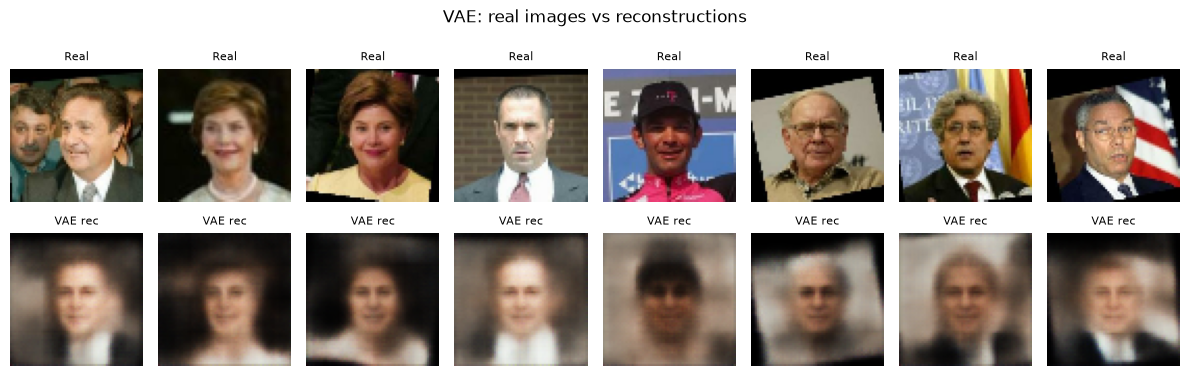

In [ ]:
# VAE reconstructions

# Берем batch реальных изображений.
real_images = next(iter(val_dataset))

# Кодируем изображения в latent-пространство.
z_mean, z_log_var, z = vae_encoder(real_images[:8])

# Восстанавливаем изображения декодером.
reconstructed_images = vae_decoder(z, training=False)

plt.figure(figsize=(12, 4))

for i in range(8):
    # Верхний ряд: реальные изображения.
    plt.subplot(2, 8, i + 1)
    real_image = (real_images[i].numpy() + 1.0) / 2.0
    real_image = np.clip(real_image, 0, 1)
    plt.imshow(real_image)
    plt.title("Real", fontsize=8)
    plt.axis("off")

    # Нижний ряд: реконструкции VAE.
    plt.subplot(2, 8, i + 1 + 8)
    reconstructed_image = (reconstructed_images[i].numpy() + 1.0) / 2.0
    reconstructed_image = np.clip(reconstructed_image, 0, 1)
    plt.imshow(reconstructed_image)
    plt.title("VAE rec", fontsize=8)
    plt.axis("off")

plt.suptitle("VAE: real images vs reconstructions")
plt.tight_layout()
plt.show()

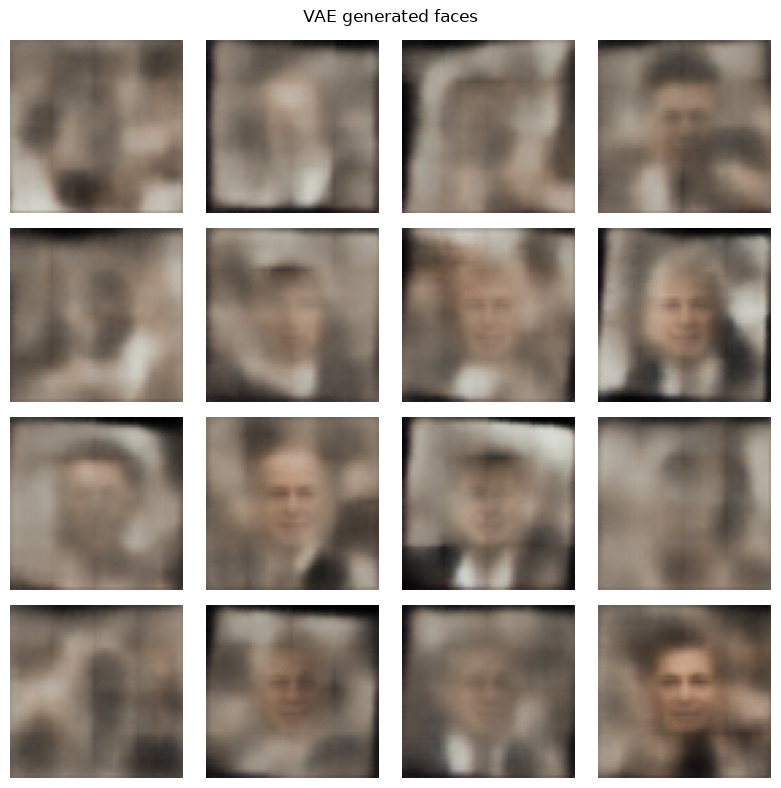

In [ ]:
# VAE generated faces from random latent vectors

# Случайные точки из latent-пространства.
vae_noise = tf.random.normal([16, VAE_LATENT_DIM])

# Декодер превращает latent-векторы в изображения.
vae_generated_images = vae_decoder(vae_noise, training=False)

plt.figure(figsize=(8, 8))

for i in range(16):
    plt.subplot(4, 4, i + 1)

    image = (vae_generated_images[i].numpy() + 1.0) / 2.0
    image = np.clip(image, 0, 1)

    plt.imshow(image)
    plt.axis("off")

plt.suptitle("VAE generated faces")
plt.tight_layout()
plt.show()

Данные были явно разделены на обучающую и валидационную выборки в пропорции 80/20. Обучение DCGAN и VAE выполнялось только на `train_dataset`, а `val_dataset` использовался для независимой визуальной проверки: сравнения реальных и сгенерированных изображений, а также реконструкций VAE. Это позволяет отделить данные, на которых модели обучались, от данных, на которых оценивается качество генерации и восстановления.

## Вывод

В работе были реализованы и сравнены два генеративных подхода для датасета LFW: DCGAN и VAE. Изображения лиц были загружены из папки `lfw-deepfunneled`, приведены к размеру `64x64`, преобразованы в RGB и нормализованы в диапазон `[-1, 1]`.

В модели DCGAN генератор преобразует случайный latent-вектор в изображение лица, а дискриминатор учится отличать реальные изображения от сгенерированных. После 10 эпох GAN начал воспроизводить общую структуру изображений из LFW: светлую область лица по центру, темный фон и примерные контуры головы. Однако сгенерированные изображения остаются размытыми и достаточно однотипными, что говорит о коротком обучении и признаках частичного mode collapse.

В модели VAE encoder переводит изображение в параметры latent-распределения (`z_mean`, `z_log_var`), sampling layer применяет reparameterization trick, а decoder восстанавливает изображение из latent-вектора. За 5 эпох `total_loss` и `reconstruction_loss` заметно снизились, поэтому VAE научился передавать общую структуру лиц. При этом `KL loss` постепенно увеличивался, что показывает вовлечение latent-пространства в обучение.

Сравнение результатов показывает, что GAN формирует более контрастные изображения, но обучение нестабильно и чувствительно к балансу генератора и дискриминатора. VAE обучается стабильнее и дает более разнообразные, но сильно сглаженные изображения. В текущем эксперименте обе модели уловили общие признаки лиц, однако качество генерации ограничено малым числом эпох и небольшим размером изображений.

Для улучшения результата можно увеличить число эпох, использовать GPU, обучать модели на изображениях большего разрешения, подобрать `learning rate`, `batch size` и размер latent-пространства, а также попробовать более устойчивые варианты GAN, например WGAN-GP.